In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
from torchaudio.datasets import SPEECHCOMMANDS
import os
import matplotlib.pyplot as plt
import IPython.display as ipd
from tqdm import tqdm
from tabulate import tabulate

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Dataset Preparation

In [3]:


class EmotionAudioDataset(Dataset):
    def __init__(self, root_dir, sample_rate=16000):
        self.root_dir = root_dir
        self.sample_rate = sample_rate
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.files = []
        
        for emotion in self.classes:
            emotion_path = os.path.join(root_dir, emotion)
            files = [(os.path.join(emotion_path, f), emotion) 
                     for f in os.listdir(emotion_path) if f.endswith(('.wav', '.mp3'))]
            print(f"{emotion}: {len(files)} files")
            self.files.extend(files)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        audio_path, emotion = self.files[idx]
        waveform, sample_rate = torchaudio.load(audio_path)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        if sample_rate != self.sample_rate:
            waveform = torchaudio.transforms.Resample(sample_rate, self.sample_rate)(waveform)
        waveform = waveform / (torch.max(torch.abs(waveform)) + 1e-8)
        label = torch.tensor(self.class_to_idx[emotion])
        return waveform, label

# Instantiate the dataset
dataset_path = "/kaggle/input/emotion/"
full_dataset = EmotionAudioDataset(dataset_path)

# Split dataset into training, validation, and test sets
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size
train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

print(f"Dataset splits: Train={len(train_set)}, Val={len(val_set)}, Test={len(test_set)}")


Angry: 216 files
Happy: 216 files
Natural: 216 files
Sad: 216 files
Surprised: 216 files
Dataset splits: Train=756, Val=162, Test=162


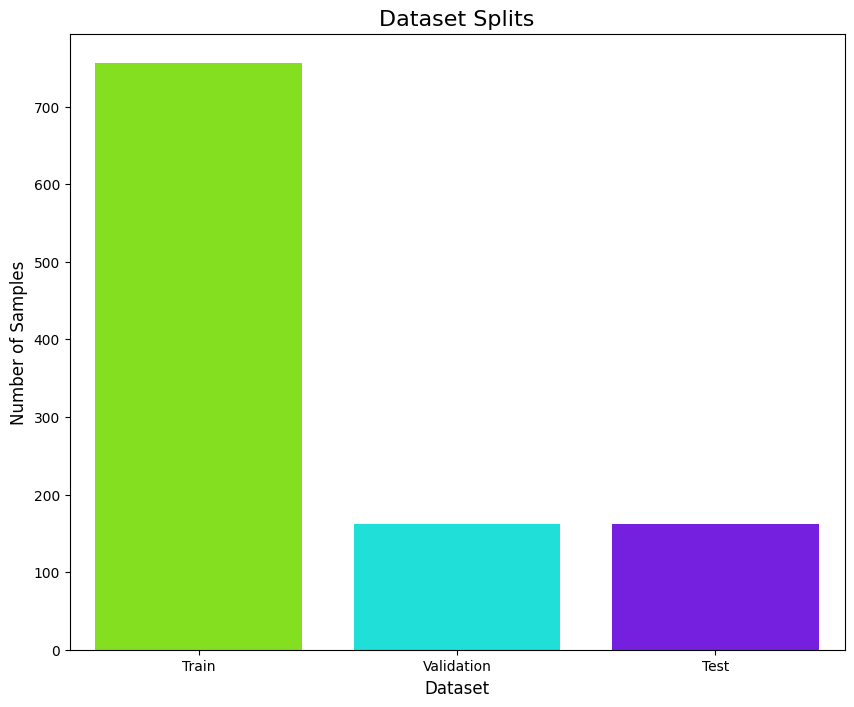

In [4]:
import seaborn as sns

import pandas as pd

split_lengths = {
    "Train": len(train_set),
    "Validation": len(val_set),
    "Test": len(test_set)
}

data = pd.DataFrame(list(split_lengths.items()), columns=["Dataset", "Count"])

plt.figure(figsize=(10, 8))
sns.barplot(x="Dataset", y="Count", data=data, palette="hsv")
plt.title("Dataset Splits", fontsize=16)
plt.xlabel("Dataset", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.show()


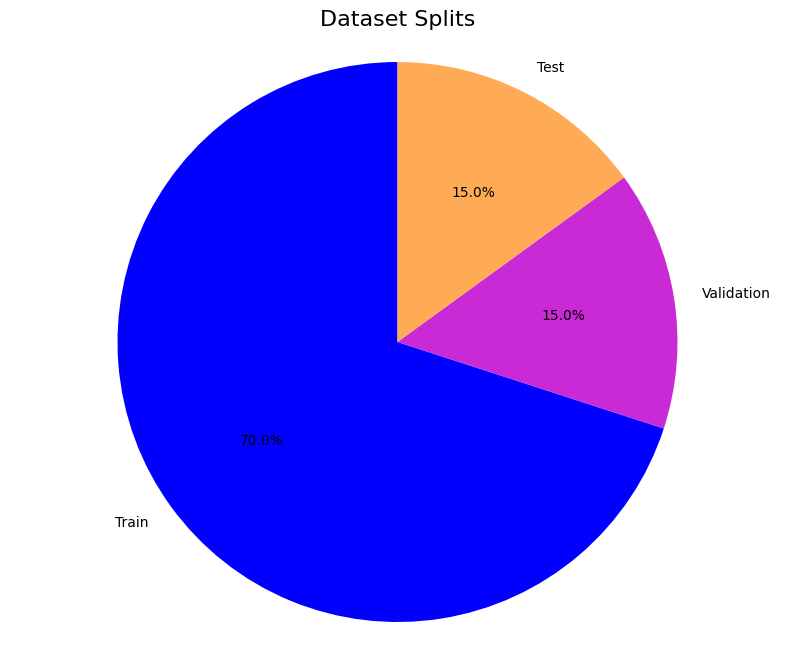

In [5]:
plt.figure(figsize=(10, 8))
plt.pie(
    split_lengths.values(),
    labels=split_lengths.keys(),
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("gnuplot2", len(split_lengths))
)
plt.title("Dataset Splits", fontsize=16)
plt.axis('equal')
plt.show()

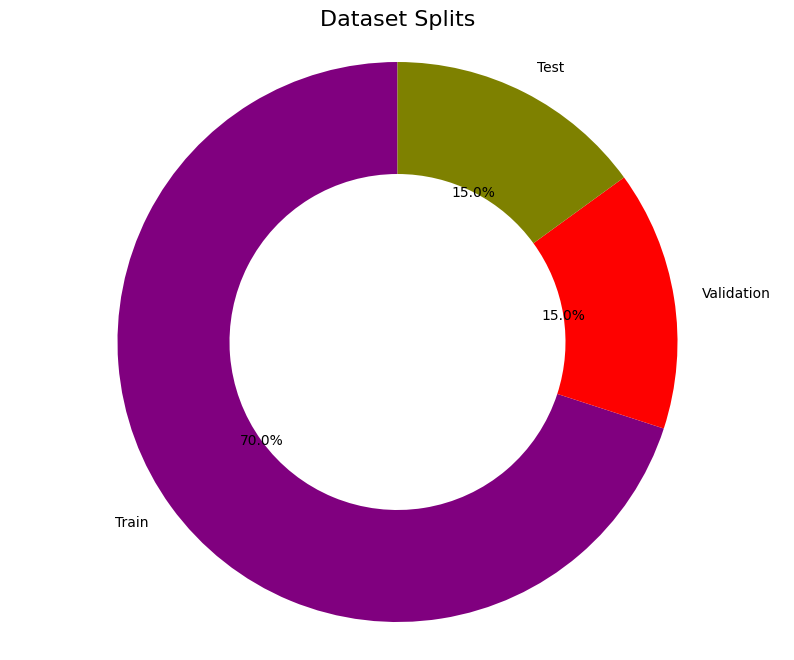

In [6]:
plt.figure(figsize=(10, 8))
plt.pie(
    split_lengths.values(),
    labels=split_lengths.keys(),
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("brg", len(split_lengths)),
    wedgeprops={'width': 0.4}
)
plt.title("Dataset Splits", fontsize=16)
plt.axis('equal')
plt.show()


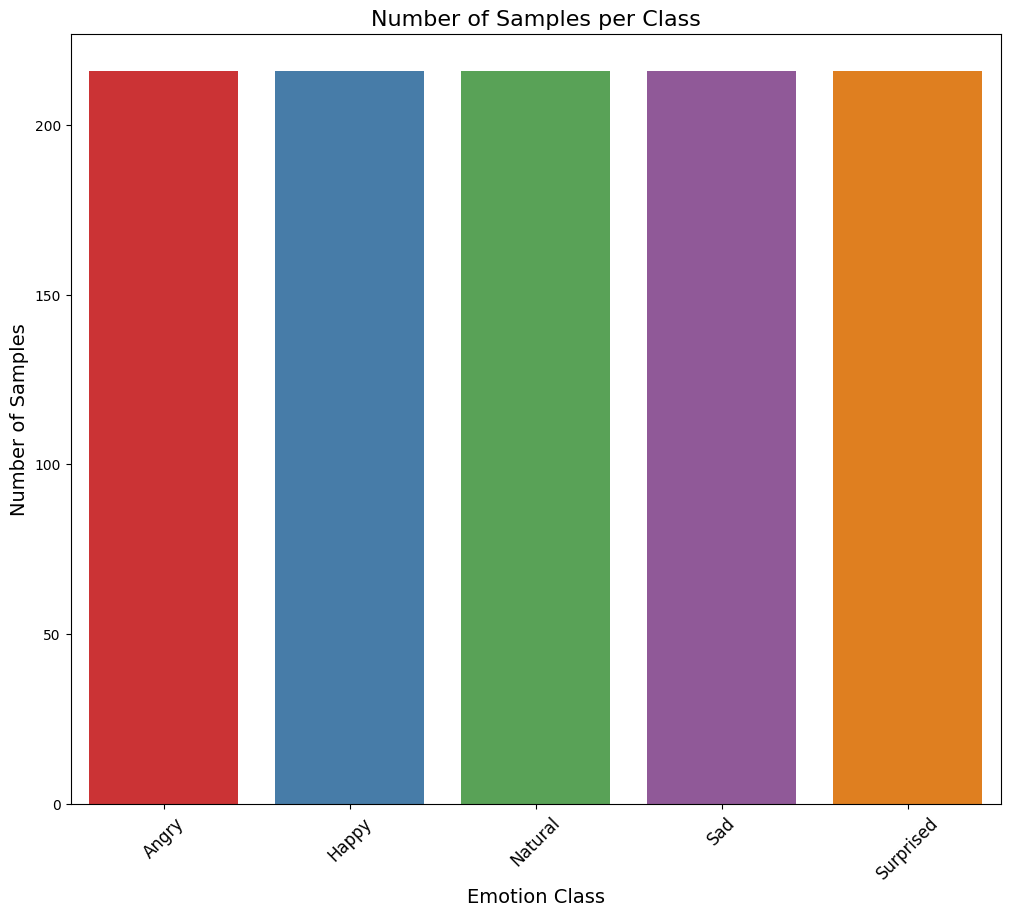

In [7]:
class_counts = {cls: 0 for cls in full_dataset.classes}
for _, emotion in full_dataset.files:
    class_counts[emotion] += 1
    
class_counts_df = pd.DataFrame({
    "Class": class_counts.keys(),
    "Count": class_counts.values()
})

plt.figure(figsize=(12, 10))
sns.barplot(data=class_counts_df, x="Class", y="Count", palette="Set1")
plt.title("Number of Samples per Class", fontsize=16)
plt.xlabel("Emotion Class", fontsize=14)
plt.ylabel("Number of Samples", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.show()


# Model Definition

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class M5(nn.Module):
    def __init__(self, n_input=1, n_output=35, stride=16, n_channel=32):
        super().__init__()
        self.conv1 = nn.Conv1d(n_input, n_channel, kernel_size=80, stride=stride)
        self.bn1 = nn.BatchNorm1d(n_channel)
        self.pool1 = nn.MaxPool1d(4)

        self.conv2 = nn.Conv1d(n_channel, n_channel, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(n_channel)
        self.pool2 = nn.MaxPool1d(4)

        self.conv3 = nn.Conv1d(n_channel, 2 * n_channel, kernel_size=3)
        self.bn3 = nn.BatchNorm1d(2 * n_channel)
        self.pool3 = nn.MaxPool1d(4)

        self.conv4 = nn.Conv1d(2 * n_channel, 2 * n_channel, kernel_size=3)
        self.bn4 = nn.BatchNorm1d(2 * n_channel)
        self.pool4 = nn.MaxPool1d(4)

        self.fc1 = nn.Linear(2 * n_channel, n_output)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(self.bn1(x))
        x = self.pool1(x)

        x = self.conv2(x)
        x = F.relu(self.bn2(x))
        x = self.pool2(x)

        x = self.conv3(x)
        x = F.relu(self.bn3(x))
        x = self.pool3(x)

        x = self.conv4(x)
        x = F.relu(self.bn4(x))
        x = self.pool4(x)

        x = F.avg_pool1d(x, x.shape[-1]).squeeze(-1)
        x = self.fc1(x)
        return F.log_softmax(x, dim=1)


n_input_channels = 1
n_classes = len(full_dataset.classes)
model = M5(n_input=n_input_channels, n_output=n_classes)
model = model.to(device)
print(model)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


n = count_parameters(model)
print("Number of parameters: %s" % n)


M5(
  (conv1): Conv1d(1, 32, kernel_size=(80,), stride=(16,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(32, 64, kernel_size=(3,), stride=(1,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
  (bn4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=64, out_features=5, bias=True)
)
Number

# Dataloader and Utility Functions

In [9]:
def collate_fn(batch):
    waveforms, labels = [], []
    max_length = max(waveform.size(1) for waveform, _ in batch)
    
    for waveform, label in batch:
        pad_amount = max_length - waveform.size(1)
        padded_waveform = F.pad(waveform, (0, pad_amount))
        waveforms.append(padded_waveform)
        labels.append(label)
    
    return torch.stack(waveforms), torch.stack(labels)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, collate_fn=collate_fn)


# Training and Evaluation

In [10]:


model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

early_stopping_patience = 5
best_val_loss = float('inf')
early_stopping_counter = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

def train_epoch(epoch, model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for waveforms, labels in tqdm(loader, desc=f"Training Epoch {epoch}", leave=False, ncols=100, colour="green"):
        waveforms, labels = waveforms.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(waveforms)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), 100 * correct / total

def evaluate(epoch, model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for waveforms, labels in tqdm(loader, desc=f"Evaluating Epoch {epoch}", leave=False, ncols=100, colour="blue"):
            waveforms, labels = waveforms.to(device), labels.to(device)
            outputs = model(waveforms)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), 100 * correct / total

num_epochs = 50
for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}")
    train_loss, train_acc = train_epoch(epoch, model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(epoch, model, val_loader, criterion)
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        print(f"No improvement in validation loss. Early stopping counter: {early_stopping_counter}")

    if early_stopping_counter >= early_stopping_patience:
        print("Early stopping triggered.")
        break



/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Epoch 1


Train Loss: 1.5161, Train Accuracy: 32.54%
Validation Loss: 1.6020, Val Accuracy: 19.75%

Epoch 2


Train Loss: 1.3456, Train Accuracy: 45.11%
Validation Loss: 1.4763, Val Accuracy: 33.95%

Epoch 3


Train Loss: 1.2289, Train Accuracy: 56.22%
Validation Loss: 1.3405, Val Accuracy: 48.15%

Epoch 4


...

Train Loss: 0.2855, Train Accuracy: 98.28%
Validation Loss: 1.0974, Val Accuracy: 54.94%
No improvement in validation loss. Early stopping counter: 2

Epoch 24


Train Loss: 0.2882, Train Accuracy: 98.02%
Validation Loss: 1.1681, Val Accuracy: 54.94%
No improvement in validation loss. Early stopping counter: 3

Epoch 25


Train Loss: 0.2495, Train Accuracy: 98.94%
Validation Loss: 1.1457, Val Accuracy: 56.17%
No improvement in validation loss. Early stopping counter: 4

Epoch 26


                                                                                                    1.51it/s]

Train Loss: 0.2430, Train Accuracy: 99.21%
Validation Loss: 1.1048, Val Accuracy: 56.79%
No improvement in validation loss. Early stopping counter: 5
Early stopping triggered.


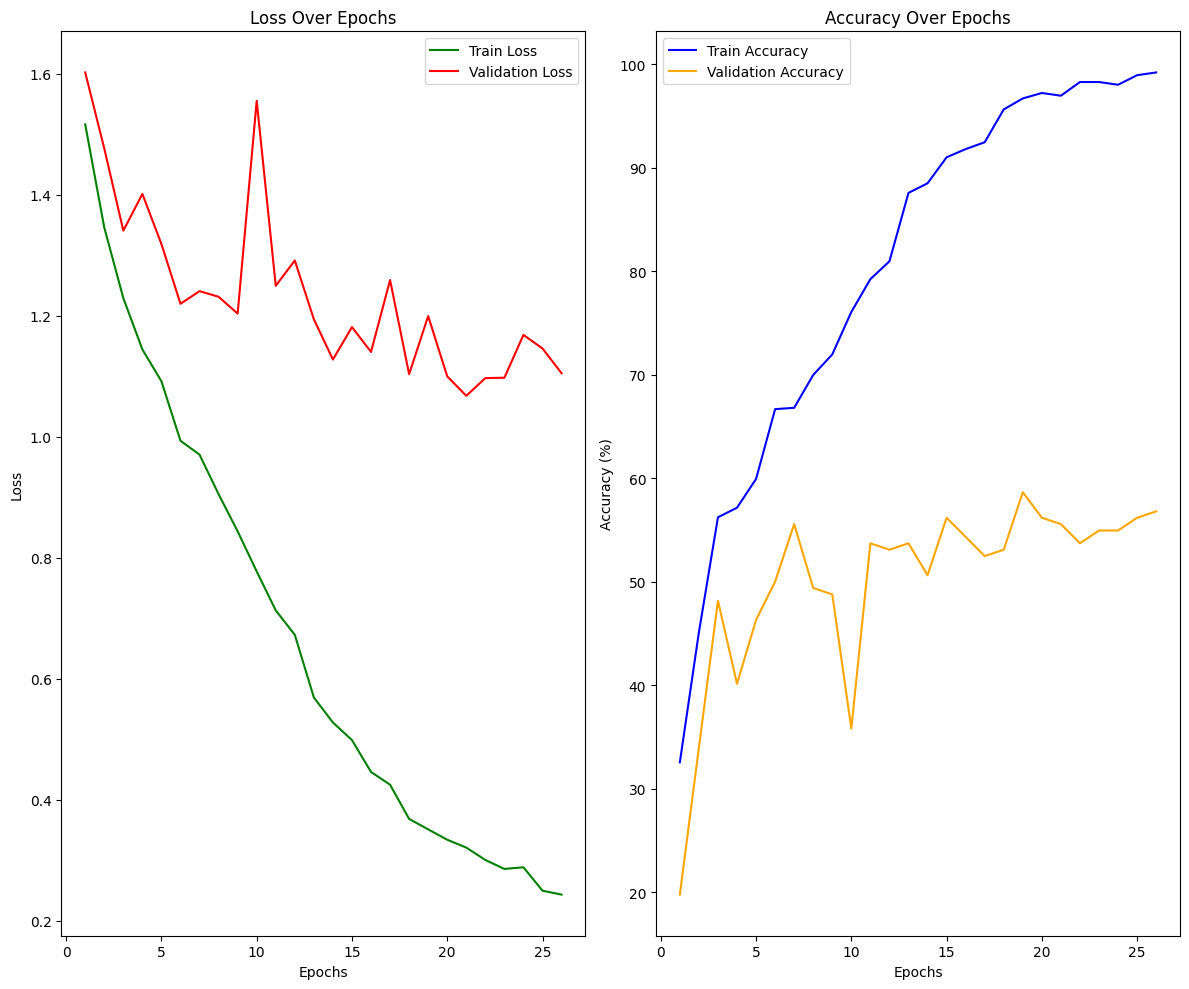

In [11]:

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 10))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', color='green')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', color='blue')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()



Accuracy: 0.6111111111111112
Precision (Weighted): 0.6337641682783927
Recall (Weighted): 0.6111111111111112
F1 Score (Weighted): 0.6088024787085698

Classification Report:
               precision    recall  f1-score   support

       Angry       0.70      0.76      0.73        42
       Happy       0.38      0.61      0.47        28
     Natural       0.81      0.85      0.83        26
         Sad       0.70      0.50      0.58        32
   Surprised       0.57      0.35      0.44        34

    accuracy                           0.61       162
   macro avg       0.63      0.61      0.61       162
weighted avg       0.63      0.61      0.61       162



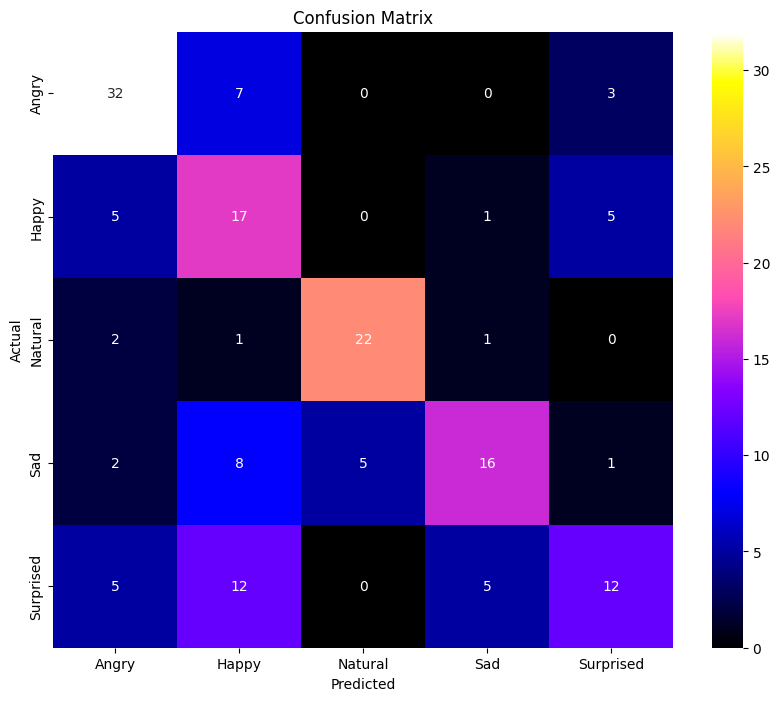

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)  
label_name=test_set.dataset.classes

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
       
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

report = classification_report(all_labels, all_preds, target_names=label_name)

print("==============================================================================")
print("\nAccuracy:", accuracy)
print("==============================================================================")
print("Precision (Weighted):", precision)
print("==============================================================================")
print("Recall (Weighted):", recall)
print("==============================================================================")
print("F1 Score (Weighted):", f1)
print("==============================================================================")
print("\nClassification Report:\n", report)
print("==============================================================================")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='gnuplot2', xticklabels=label_name, yticklabels=label_name)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Roc Curve

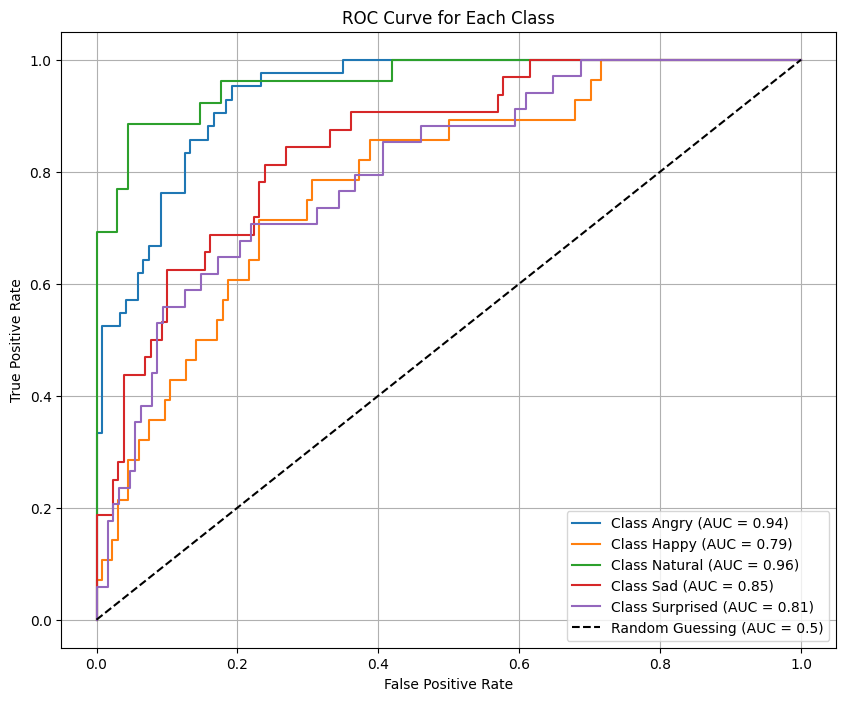

In [22]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
class_names = test_set.dataset.classes
all_labels_bin = label_binarize(all_labels, classes=range(len(class_names)))

model.eval()
all_preds_proba = []

model.to(device)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        all_preds_proba.extend(probs.cpu().numpy())

all_preds_proba = np.array(all_preds_proba)

plt.figure(figsize=(10, 8))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_preds_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# Precision recall curve

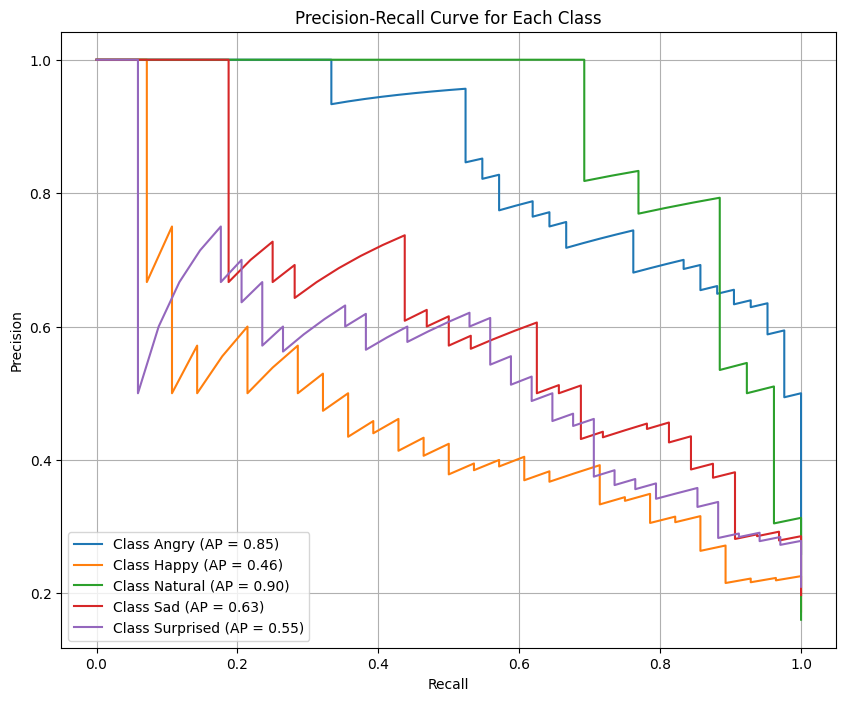

In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

all_labels_bin = label_binarize(all_labels, classes=range(len(label_name)))

model.eval()
all_preds_proba = []


model.to(device)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        all_preds_proba.extend(probs.cpu().numpy())

all_preds_proba = np.array(all_preds_proba)

plt.figure(figsize=(10, 8))

for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(all_labels_bin[:, i], all_preds_proba[:, i])
    avg_precision = average_precision_score(all_labels_bin[:, i], all_preds_proba[:, i])
    plt.plot(recall, precision, label=f'Class {class_names[i]} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Each Class')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


In [26]:
import torch
import torchaudio

def predict_emotion(model, audio_file, class_to_idx, device):
    waveform, sample_rate = torchaudio.load(audio_file)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    waveform = torchaudio.transforms.Resample(sample_rate, 16000)(waveform)
    waveform = waveform / (torch.max(torch.abs(waveform)) + 1e-8)
    waveform = waveform.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(waveform)
        _, predicted_idx = torch.max(output, 1)

    predicted_emotion = [emotion for emotion, idx in class_to_idx.items() if idx == predicted_idx.item()]
    return predicted_emotion[0] if predicted_emotion else "Unknown"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

audio_file = "/kaggle/input/emotion/Angry/03-01-03-02-01-01-03.wav"  
predicted_emotion = predict_emotion(model, audio_file, full_dataset.class_to_idx, device)
print(f"Predicted Emotion: {predicted_emotion}")


Predicted Emotion: Angry


In [27]:
! pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 31.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.8/321.8 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 110.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [36]:
import gradio as gr
import torch
import torchaudio

def predict_emotion(model, audio_file, class_to_idx, device):
    waveform, sample_rate = torchaudio.load(audio_file)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    waveform = torchaudio.transforms.Resample(sample_rate, 16000)(waveform)
    waveform = waveform / (torch.max(torch.abs(waveform)) + 1e-8)
    waveform = waveform.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(waveform)
        _, predicted_idx = torch.max(output, 1)

    predicted_emotion = [emotion for emotion, idx in class_to_idx.items() if idx == predicted_idx.item()]
    return predicted_emotion[0] if predicted_emotion else "Unknown"


def gradio_predict(audio_file):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    predicted_emotion = predict_emotion(model, audio_file, full_dataset.class_to_idx, device)
    return predicted_emotion

iface = gr.Interface(fn=gradio_predict, inputs=gr.Audio(type="filepath"), outputs="text")
iface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7866
* Running on public URL: https://a258b49d1644f85d0d.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
